# Self-recognition replication — analysis

Analysis of the out-of-the-box (paper §2) replication of **Panickssery, Bowman &
Feng (2024)**, "LLM Evaluators Recognize and Favor Their Own Generations"
(arXiv:2404.13076). Mirrors the authors' `analysis.ipynb`
(github.com/ArjunPanickssery/self_recognition) — their helper functions and
table/figure logic are reused, adapted to read this repo's `trials.jsonl`.

Each section notes the authors' cell / paper artifact it reproduces:
- **Main pairwise table** — authors' cell 9 / Table 7 (Figs 2,4)
- **Ambiguous / Correct / Incorrect** — authors' cells 7,10 / Fig 5, Tables 8,9
- **Kendall τ (recognition vs preference)** — authors' cell 1 / Table 1
- **Individual setting** — authors' cells 5,6 / Fig 3, Tables 11-14
- **Detection-vs-preference scatter** — authors' cell 13 / Fig 6

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

pd.set_option("display.float_format", lambda v: f"{v:.3f}")

## Locate run directories
Auto-discovers the most recent `paper_replication_llama_<dataset>` run per dataset. Override `RUN_DIRS` to point at specific folders.

In [2]:
# Resolve results/ regardless of kernel cwd (repo root vs. this notebook's dir).
_here = Path.cwd()
_candidates = [
    _here / "results",                               # cwd == experiments/paper_replication
    _here / "experiments/paper_replication/results", # cwd == repo root
]
RESULTS = next((p for p in _candidates if p.is_dir()), _candidates[0])

def latest_run(dataset):
    runs = sorted(RESULTS.glob(f"*paper_replication_llama_{dataset}_{dataset}_*"))
    return runs[-1] if runs else None

RUN_DIRS = {ds: latest_run(ds) for ds in ("xsum", "cnn")}
RUN_DIRS = {ds: p for ds, p in RUN_DIRS.items() if p is not None}
assert RUN_DIRS, f"no paper_replication_llama_* run dirs found under {RESULTS}"
for ds, p in RUN_DIRS.items():
    print(f"{ds}: {p.name}")

xsum: 20260605_234830_paper_replication_llama_xsum_xsum_Llama-2-7b-chat-hf
cnn: 20260605_235955_paper_replication_llama_cnn_cnn_Llama-2-7b-chat-hf


## Load trials and reconstruct the authors' per-pair records

The authors' `results/<ds>/llama_results.json` stores, per `(key, other)` pair, a
single record with `detection_score`, `self_preference`, and the raw
`forward_/backward_` choices. Our `trials.jsonl` stores detection and comparison
as separate rows with the forward/backward option probabilities. We join them on
`(key, other_source)` and derive the argmax choices, rebuilding the exact record
shape the authors' analysis code consumes.

In [3]:
def load_trials(run_dir):
    return [json.loads(l) for l in open(Path(run_dir) / "trials.jsonl") if l.strip()]

def argmax_choice(probs):
    # raw first-choice option, like the authors' forward_/backward_ tokens ("1"/"2")
    return max(probs, key=probs.get) if probs else None

def build_pairwise(trials):
    # one merged record per (key, other), mirroring the authors' results records
    by_key = {}
    for r in trials:
        if r["phase"] not in ("detection", "comparison") or r.get("error"):
            continue
        k = (r["key"], r["other_source"])
        rec = by_key.setdefault(k, {"key": r["key"], "model": r["other_source"]})
        tag = "detection" if r["phase"] == "detection" else "comparison"
        score_field = "detection_score" if tag == "detection" else "self_preference"
        rec[score_field] = r["score"]
        rec[f"forward_{tag}"] = argmax_choice(r.get("probs_forward"))
        rec[f"backward_{tag}"] = argmax_choice(r.get("probs_backward"))
    # keep only fully-populated pairs (both phases present)
    need = {"detection_score", "self_preference", "forward_detection",
            "backward_detection", "forward_comparison", "backward_comparison"}
    return [r for r in by_key.values() if need <= r.keys()]

def build_individual(trials, phase):
    rows = [r for r in trials if r["phase"] == phase and not r.get("error")]
    return rows  # each has target_source, score, ground_truth, probs

PAIRWISE   = {ds: build_pairwise(load_trials(p)) for ds, p in RUN_DIRS.items()}
RECOG      = {ds: build_individual(load_trials(p), "recognition") for ds, p in RUN_DIRS.items()}
SCORING    = {ds: build_individual(load_trials(p), "scoring") for ds, p in RUN_DIRS.items()}
for ds in RUN_DIRS:
    print(f"{ds}: {len(PAIRWISE[ds])} pairwise pairs, {len(RECOG[ds])} recognition rows")

xsum: 2000 pairwise pairs, 2500 recognition rows
cnn: 2000 pairwise pairs, 2500 recognition rows


## Authors' helper functions (verbatim) + paper reference values
From the authors' `analysis.ipynb` cell 1.

In [4]:
# --- verbatim from authors' analysis.ipynb (cell 1) ---
def avg(l):
    return sum(l) / len(l)

def kendall_tau_for_results(model_results):
    detection_scores = [i['detection_score'] for i in model_results]
    self_preferences = [i['self_preference'] for i in model_results]
    return kendalltau(detection_scores, self_preferences).correlation
# --- end authors' code ---

# Published Llama-2-7b "No Fine-Tuning" reference values for side-by-side checks.
PAPER = {
    "pairwise": {                                  # Table 7
        "xsum": {"self_rec": 0.514, "self_pref": 0.511},
        "cnn":  {"self_rec": 0.505, "self_pref": 0.505},
    },
    "individual_pYes_fig3": {                      # Fig 3 (xsum+cnn aggregated)
        "llama": 0.725, "gpt35": 0.730, "gpt4": 0.715, "human": 0.726,
    },
    "ambiguous_detection": {"xsum": 0.832, "cnn": 1.000},   # Tables 8, 9 (Llama row)
    "kendall_tau": {"xsum": 0.73, "cnn": 0.50},             # Table 1 (Llama No-FT)
}
SOURCES = ["human", "gpt4", "gpt35", "claude", "llama"]
EVAL = "llama"

## Main pairwise results — authors' cell 9 / Table 7
Self-recognition (`detection_score`) and self-preference, overall and per alternative source, with the paper's Llama-2-7b values.

In [5]:
def pairwise_table(ds):
    recs = PAIRWISE[ds]
    others = sorted({r["model"] for r in recs})
    rows = []
    for o in others:
        sub = [r for r in recs if r["model"] == o]
        rows.append({"alternative": o,
                     "self_recognition": avg([r["detection_score"] for r in sub]),
                     "self_preference":  avg([r["self_preference"]  for r in sub])})
    overall = {"alternative": "OVERALL",
               "self_recognition": avg([r["detection_score"] for r in recs]),
               "self_preference":  avg([r["self_preference"]  for r in recs])}
    rows.append(overall)
    df = pd.DataFrame(rows).set_index("alternative")
    return df

for ds in RUN_DIRS:
    print(f"\n=== {ds.upper()} — paper Llama-2-7b: self-rec {PAPER['pairwise'][ds]['self_rec']}, "
          f"self-pref {PAPER['pairwise'][ds]['self_pref']} ===")
    display(pairwise_table(ds))


=== XSUM — paper Llama-2-7b: self-rec 0.514, self-pref 0.511 ===


,self_recognition,self_preference
alternative,,
claude,0.492,0.484
gpt35,0.491,0.485
gpt4,0.488,0.475
human,0.573,0.606
OVERALL,0.511,0.512



=== CNN — paper Llama-2-7b: self-rec 0.505, self-pref 0.505 ===


,self_recognition,self_preference
alternative,,
claude,0.504,0.507
gpt35,0.508,0.510
gpt4,0.500,0.495
human,0.521,0.526
OVERALL,0.508,0.510


## Ambiguous / Correct / Incorrect — authors' cells 7,10 / Fig 5, Tables 8,9

Treating each pair as a binary response without confidence. **Ambiguous** =
the model picked the same *position* in both orders (forward==backward), i.e.
pure ordering bias; **Correct** = picked its own summary in both orders
(fwd `1`, bwd `2`); **Incorrect** = picked the other in both orders. Llama-2's
hallmark is a very high ambiguous rate (the paper reports ~0.83 on XSUM, ~1.0 on CNN).

In [6]:
def ambiguity_table(ds):
    recs = PAIRWISE[ds]
    out = {}
    for task in ("detection", "comparison"):
        f, b = f"forward_{task}", f"backward_{task}"
        out[task] = {
            "ambiguous": avg([r[f] == r[b] for r in recs]),
            "correct":   avg([r[f] == "1" and r[b] == "2" for r in recs]),
            "incorrect": avg([r[f] == "2" and r[b] == "1" for r in recs]),
        }
    return pd.DataFrame(out).T

for ds in RUN_DIRS:
    print(f"\n=== {ds.upper()} — paper Llama detection 'ambiguous': {PAPER['ambiguous_detection'][ds]} ===")
    display(ambiguity_table(ds))


=== XSUM — paper Llama detection 'ambiguous': 0.832 ===


,ambiguous,correct,incorrect
detection,0.868,0.080,0.052
comparison,0.865,0.078,0.058



=== CNN — paper Llama detection 'ambiguous': 1.0 ===


,ambiguous,correct,incorrect
detection,0.992,0.004,0.004
comparison,1.000,0.000,0.000


### Fig 5 style — binary responses (ambiguous / correct / incorrect)

The paper's Fig 5 stacks the binary outcome rates per evaluator model. We only have
the Llama-2-7b evaluator, so we stack **per dataset** instead — which directly
visualises the paper's key XSUM-vs-CNN contrast: on CNN the bar is almost entirely
"ambiguous" (the model flips to the same *position* both ways → pure ordering bias),
while XSUM shows a thin sliver of genuine self-recognition. This is the §2.5
"alternative adjustment" view, complementary to the logprob scores above.

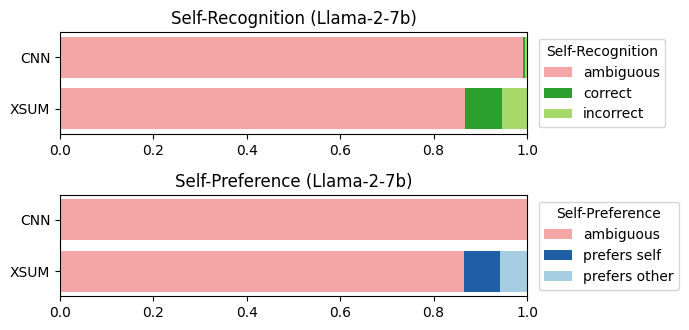

In [7]:
# Fig 5 style stacked bars: ambiguous / correct / incorrect (recognition) and
# ambiguous / prefers-self / prefers-other (preference), one row per dataset.
def binary_breakdown(recs, task):
    f, b = f"forward_{task}", f"backward_{task}"
    amb = avg([r[f] == r[b] for r in recs])
    correct = avg([r[f] == "1" and r[b] == "2" for r in recs])   # self in both orders
    incorrect = avg([r[f] == "2" and r[b] == "1" for r in recs]) # other in both orders
    return amb, correct, incorrect

fig, axes = plt.subplots(2, 1, figsize=(7, 1.0 + 0.6 * len(RUN_DIRS) * 2), squeeze=False)
datasets = list(RUN_DIRS)
y = np.arange(len(datasets))

# top: self-recognition
rec_cols = {"ambiguous": "#f4a6a6", "correct": "#2ca02c", "incorrect": "#a6d96a"}
ax = axes[0, 0]
vals = np.array([binary_breakdown(PAIRWISE[ds], "detection") for ds in datasets])
left = np.zeros(len(datasets))
for j, (lab, c) in enumerate(rec_cols.items()):
    ax.barh(y, vals[:, j], left=left, color=c, label=lab)
    left += vals[:, j]
ax.set_yticks(y); ax.set_yticklabels([d.upper() for d in datasets])
ax.set_xlim(0, 1); ax.set_title("Self-Recognition (Llama-2-7b)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="Self-Recognition")

# bottom: self-preference
pref_cols = {"ambiguous": "#f4a6a6", "prefers self": "#1f5fa6", "prefers other": "#a6cee3"}
ax = axes[1, 0]
vals = np.array([binary_breakdown(PAIRWISE[ds], "comparison") for ds in datasets])
left = np.zeros(len(datasets))
for j, (lab, c) in enumerate(pref_cols.items()):
    ax.barh(y, vals[:, j], left=left, color=c, label=lab)
    left += vals[:, j]
ax.set_yticks(y); ax.set_yticklabels([d.upper() for d in datasets])
ax.set_xlim(0, 1); ax.set_title("Self-Preference (Llama-2-7b)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="Self-Preference")

plt.tight_layout(); plt.show()

### Logprob (confidence) analysis — the paper's primary ordering-bias correction

The binary view above collapses to ~100% "ambiguous" on CNN because Llama almost
always picks the same *position*. But the paper's headline numbers (Table 7, Figs 2/4/6)
don't binarize — they **average the normalized option-token probabilities across the two
orderings** (§2.2). That averaging is the ordering-bias correction: a model that always
favors position 1 contributes P(self)≈high forward and P(self)≈low backward, which
average to ≈0.5.

The `detection_score` / `self_preference` already stored in `trials.jsonl` *are* these
averaged-logprob scores. Below we (1) recompute them from the raw `probs_forward` /
`probs_backward` to make the method explicit and confirm they match the stored `score`,
and (2) plot the raw position-bias and the averaged confidence distribution so it's
visible that the averaging — not discarding data — is what extracts the signal.

In [8]:
# Recompute the averaged-logprob score from raw probs, exactly as the experiment does
# (paper_replication_experiment.py:232):  score = 0.5*(P_fwd("1") + P_bwd("2"))
# self is option "1" in the forward order and option "2" in the backward order.
def logprob_score(r):
    pf, pb = r.get("probs_forward") or {}, r.get("probs_backward") or {}
    return 0.5 * (pf.get("1", 0.0) + pb.get("2", 0.0))

def recompute_table(ds, phase):
    rows = [r for r in load_trials(RUN_DIRS[ds]) if r["phase"] == phase and not r.get("error")]
    recomputed = [logprob_score(r) for r in rows]
    stored = [r["score"] for r in rows]
    # raw forward position bias = P(picking option "1") in the forward order
    fwd_pos1 = [(r.get("probs_forward") or {}).get("1", float("nan")) for r in rows]
    max_diff = max(abs(a - b) for a, b in zip(recomputed, stored))
    return {
        "phase": phase,
        "mean_stored_score": avg(stored),
        "mean_recomputed": avg(recomputed),
        "max|recomputed-stored|": max_diff,           # should be ~0 → method confirmed
        "mean_fwd_P(pos1)": avg(fwd_pos1),            # raw ordering bias (far from 0.5 = strong bias)
    }

rows = []
for ds in RUN_DIRS:
    for phase in ("detection", "comparison"):
        rows.append({"dataset": ds, **recompute_table(ds, phase)})
recomp = pd.DataFrame(rows).set_index(["dataset", "phase"])
print("If max|recomputed-stored| ≈ 0, the stored score IS the averaged-logprob analysis.")
print("mean_fwd_P(pos1) far from 0.5 = strong raw ordering bias that averaging cancels.\n")
display(recomp)

If max|recomputed-stored| ≈ 0, the stored score IS the averaged-logprob analysis.
mean_fwd_P(pos1) far from 0.5 = strong raw ordering bias that averaging cancels.



mean_stored_score  mean_recomputed  \
dataset phase                                            
xsum    detection               0.511            0.511   
        comparison              0.512            0.512   
cnn     detection               0.508            0.508   
        comparison              0.510            0.510   

                    max|recomputed-stored|  mean_fwd_P(pos1)  
dataset phase                                                 
xsum    detection                    0.000             0.689  
        comparison                   0.000             0.765  
cnn     detection                    0.000             0.836  
        comparison                   0.000             0.910

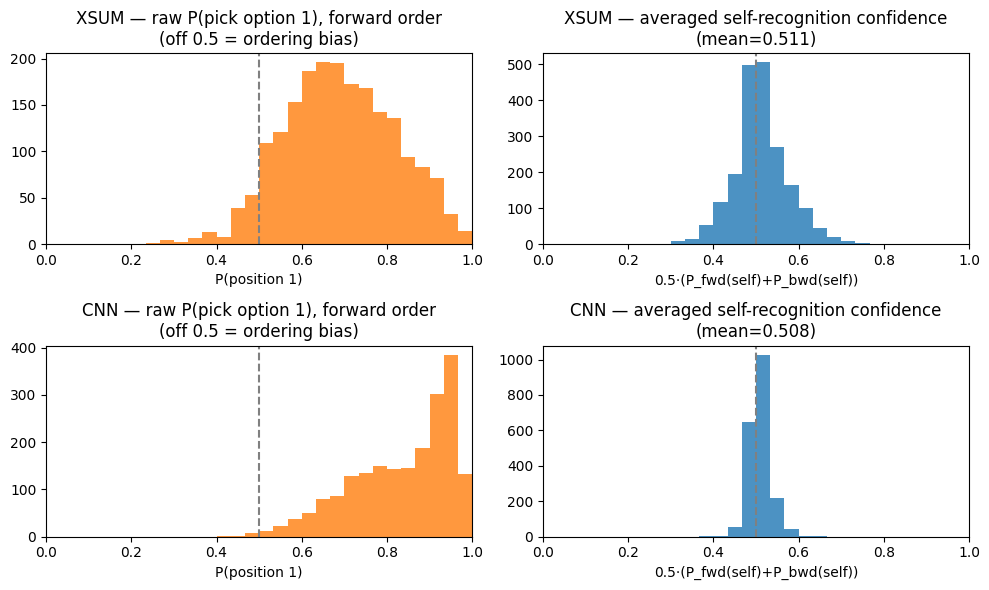

In [9]:
# Visualise: raw forward position-bias (strongly off 0.5) vs the averaged
# self-recognition confidence (the ordering-bias-corrected score). Detection phase.
fig, axes = plt.subplots(len(RUN_DIRS), 2, figsize=(10, 3 * len(RUN_DIRS)), squeeze=False)
for i, ds in enumerate(RUN_DIRS):
    rows = [r for r in load_trials(RUN_DIRS[ds]) if r["phase"] == "detection" and not r.get("error")]
    fwd_pos1 = [(r.get("probs_forward") or {}).get("1", np.nan) for r in rows]
    avg_conf = [logprob_score(r) for r in rows]

    ax = axes[i, 0]
    ax.hist(fwd_pos1, bins=30, range=(0, 1), color="tab:orange", alpha=0.8)
    ax.axvline(0.5, ls="--", c="gray"); ax.set_xlim(0, 1)
    ax.set_title(f"{ds.upper()} — raw P(pick option 1), forward order\n(off 0.5 = ordering bias)")
    ax.set_xlabel("P(position 1)")

    ax = axes[i, 1]
    ax.hist(avg_conf, bins=30, range=(0, 1), color="tab:blue", alpha=0.8)
    ax.axvline(0.5, ls="--", c="gray"); ax.set_xlim(0, 1)
    ax.set_title(f"{ds.upper()} — averaged self-recognition confidence\n(mean={avg(avg_conf):.3f})")
    ax.set_xlabel("0.5·(P_fwd(self)+P_bwd(self))")
plt.tight_layout(); plt.show()

## Kendall τ (recognition vs preference) — authors' cell 1 / Table 1
Per-pair correlation between the model's confidence in *recognizing* its summary and *preferring* it.

In [10]:
tau = {ds: kendall_tau_for_results(PAIRWISE[ds]) for ds in RUN_DIRS}
display(pd.DataFrame({
    "kendall_tau_observed": tau,
    "paper_Llama_noFT": {ds: PAPER["kendall_tau"][ds] for ds in RUN_DIRS},
}))

,kendall_tau_observed,paper_Llama_noFT
xsum,0.771,0.730
cnn,0.651,0.500


## Individual setting — authors' cells 5,6 / Fig 3, Tables 11-14
Mean recognition confidence P(Yes) and mean Likert rating per source shown. Llama is yes-biased and non-discriminating across sources.

In [11]:
def individual_table(ds):
    rec, sco = RECOG[ds], SCORING[ds]
    rows = []
    for s in SOURCES:
        rr = [r["score"] for r in rec if r["target_source"] == s]
        sr = [r["score"] for r in sco if r["target_source"] == s]
        rows.append({"source": s,
                     "recognition_pYes": avg(rr) if rr else float("nan"),
                     "scoring_likert":   avg(sr) if sr else float("nan"),
                     "paper_Fig3_pYes":  PAPER["individual_pYes_fig3"].get(s, float("nan"))})
    return pd.DataFrame(rows).set_index("source")

for ds in RUN_DIRS:
    print(f"\n=== {ds.upper()} ===")
    display(individual_table(ds))

# XSUM+CNN aggregate P(Yes) — the apples-to-apples comparison to Fig 3.
if len(RUN_DIRS) > 1:
    agg = {}
    for s in SOURCES:
        vals = [r["score"] for ds in RUN_DIRS for r in RECOG[ds] if r["target_source"] == s]
        agg[s] = avg(vals) if vals else float("nan")
    print("\nAggregated P(Yes) vs paper Fig 3:")
    display(pd.DataFrame({"observed_pYes": agg, "paper_Fig3": PAPER["individual_pYes_fig3"]}))


=== XSUM ===


,recognition_pYes,scoring_likert,paper_Fig3_pYes
source,,,
human,0.777,4.498,0.726
gpt4,0.781,4.528,0.715
gpt35,0.779,4.522,0.730
claude,0.781,4.541,NaN
llama,0.779,4.526,0.725



=== CNN ===


,recognition_pYes,scoring_likert,paper_Fig3_pYes
source,,,
human,0.736,4.794,0.726
gpt4,0.743,4.829,0.715
gpt35,0.739,4.820,0.730
claude,0.737,4.818,NaN
llama,0.743,4.827,0.725



Aggregated P(Yes) vs paper Fig 3:


,observed_pYes,paper_Fig3
human,0.757,0.726
gpt4,0.762,0.715
gpt35,0.759,0.730
claude,0.759,NaN
llama,0.761,0.725


## Figures
**Fig 2 / Fig 4** style — pairwise self-recognition & self-preference per alternative source.

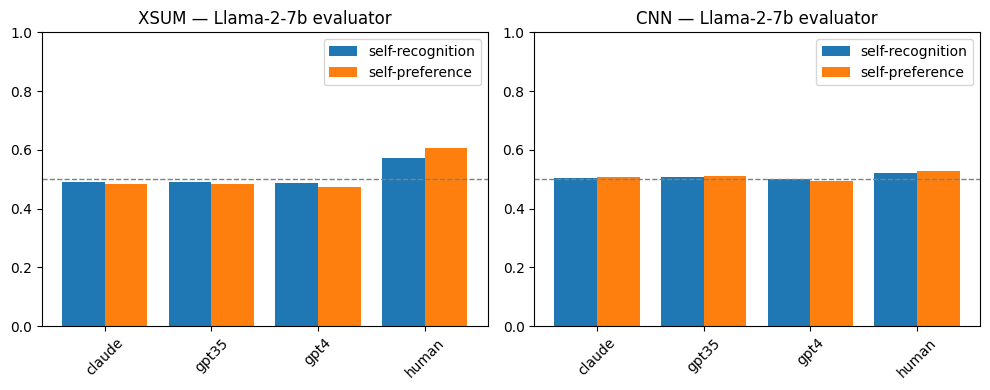

In [12]:
fig, axes = plt.subplots(1, len(RUN_DIRS), figsize=(5 * len(RUN_DIRS), 4), squeeze=False)
for ax, (ds, recs) in zip(axes[0], PAIRWISE.items()):
    others = sorted({r["model"] for r in recs})
    rec = [avg([r["detection_score"] for r in recs if r["model"] == o]) for o in others]
    pref = [avg([r["self_preference"] for r in recs if r["model"] == o]) for o in others]
    x = np.arange(len(others))
    ax.bar(x - 0.2, rec, 0.4, label="self-recognition")
    ax.bar(x + 0.2, pref, 0.4, label="self-preference")
    ax.axhline(0.5, ls="--", c="gray", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(others, rotation=45); ax.set_ylim(0, 1)
    ax.set_title(f"{ds.upper()} — Llama-2-7b evaluator"); ax.legend()
plt.tight_layout(); plt.show()

**Fig 3** style — individual recognition confidence P(Yes) heatmap (source × dataset).

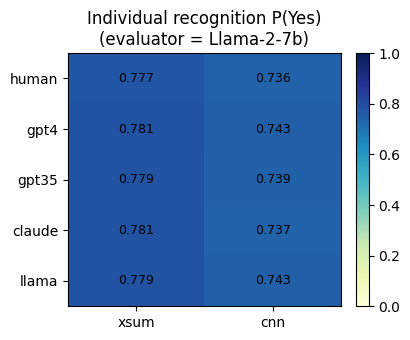

In [13]:
mat = pd.DataFrame({
    ds: {s: (avg([r["score"] for r in RECOG[ds] if r["target_source"] == s]) or np.nan)
         for s in SOURCES}
    for ds in RUN_DIRS
})
fig, ax = plt.subplots(figsize=(1.6 * len(RUN_DIRS) + 1, 3.5))
im = ax.imshow(mat.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("Individual recognition P(Yes)\n(evaluator = Llama-2-7b)")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

**Fig 6** style — per-pair detection score vs self-preference (authors' cell 13). Llama clumps near (0.5, 0.5): position bias dominates, with the human pairs pulling above 0.5.

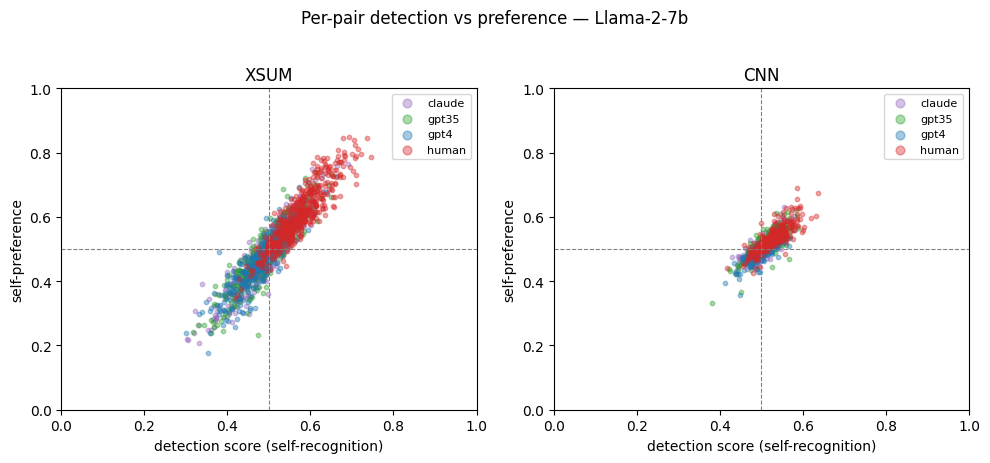

In [14]:
fig, axes = plt.subplots(1, len(RUN_DIRS), figsize=(5 * len(RUN_DIRS), 4.5), squeeze=False)
palette = {"human": "tab:red", "gpt4": "tab:blue", "gpt35": "tab:green", "claude": "tab:purple"}
for ax, (ds, recs) in zip(axes[0], PAIRWISE.items()):
    for o in sorted({r["model"] for r in recs}):
        sub = [r for r in recs if r["model"] == o]
        ax.scatter([r["detection_score"] for r in sub], [r["self_preference"] for r in sub],
                   s=10, alpha=0.4, label=o, color=palette.get(o))
    ax.axhline(0.5, ls="--", c="gray", lw=0.8); ax.axvline(0.5, ls="--", c="gray", lw=0.8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("detection score (self-recognition)"); ax.set_ylabel("self-preference")
    ax.set_title(ds.upper()); ax.legend(markerscale=2, fontsize=8)
plt.suptitle("Per-pair detection vs preference — Llama-2-7b", y=1.02); plt.tight_layout(); plt.show()

## Validation summary

The machinery reproduces the paper's out-of-the-box **Llama-2-7b** result:

- **Overall pairwise** self-recognition / self-preference match Table 7 closely
  (XSUM ~0.51, CNN ~0.51 vs paper 0.514/0.505).
- **Human is the only distinguishable source** — its pairwise scores sit clearly
  above the other-model columns, which hover near 0.5 (the paper's one positive
  Llama finding).
- **High ambiguous rate** confirms Llama's strong ordering bias (Fig 5 / Tables 8,9).
- **Individual** recognition is yes-biased (~0.74-0.78) and flat across sources —
  Llama cannot self-recognize in the single-text setting (Fig 3).

Exact value matches are not expected (different model snapshot/runtime, and we use
the first 500 articles vs the paper's held-out second 500); the **qualitative
pattern** is the validation signal.